# Lecture 3 Demo: ML Fundamentals

## Imports

In [1]:
# import the libraries
import os
import sys
sys.path.append(os.path.join("code"))
from plotting_functions import *
from utils import *

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline

DATA_DIR = os.path.join("data/")
pd.set_option("display.max_colwidth", 200)

## The Dataset

Let's bring back King County housing sale prediction data from the course introduction video. You can download the data from [here](https://www.kaggle.com/harlfoxem/housesalesprediction). 

In [2]:
housing_df = pd.read_csv(DATA_DIR + 'kc_house_data.csv')
housing_df

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


## What's the Question?

The question we are considering is:

**Given a particular property in King County with some features, how should we assess that property's value (price) ?**

> Is this a classification problem or a regression problem? 

## Exploratory Data Analysis

In [3]:
# How many data points do we have? 
housing_df.shape

(21613, 21)

In [4]:
# What are the columns in the dataset? 
list(housing_df.columns)

['id',
 'date',
 'price',
 'bedrooms',
 'bathrooms',
 'sqft_living',
 'sqft_lot',
 'floors',
 'waterfront',
 'view',
 'condition',
 'grade',
 'sqft_above',
 'sqft_basement',
 'yr_built',
 'yr_renovated',
 'zipcode',
 'lat',
 'long',
 'sqft_living15',
 'sqft_lot15']

Let's explore some features. Let's try the `describe()` method

In [5]:
housing_df.describe(include='all')

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,21613,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,...,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
unique,NaN,372,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,20140623T000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,142,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,4.580302e+09,NaN,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,...,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,NaN,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,...,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,NaN,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,...,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,NaN,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,...,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,NaN,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,...,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,NaN,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,...,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000


Do we need to keep all the columns? 

### Activity: Discuss the following questions in your group

- Which columns should we keep and which ones should we drop? Why?
- Fill out this table in Markdown with your group:

| Feature       | Keep or Discard | Why? |
|---------------|-----------------|------|
| bathrooms     |        k         |      |
| bedrooms      |        k         |      |
| condition     |        k        |      |
| date          |        d         |      |
| floors        |         k        |      |
| grade         |        d         |      |
| id            |         d        |      |
| lat           |         k        |      |
| long          |         k        |      |
| price         |         k        |      |
| sqft_above    |         k        |      |
| sqft_basement |          k       |      |
| sqft_living   |          k       |      |
| sqft_living15 |         d        |      |
| sqft_lot      |         k        |      |
| sqft_lot15    |          d       |      |
| view          |             k    |      |
| waterfront    |       d          |      |
| yr_built      |       k          |      |
| yr_renovated  |            k     |      |
| zipcode       |         d        |      |

In [6]:
housing_df['id'].unique().shape[0]

21436

In [7]:
housing_df['zipcode'].value_counts()

zipcode
98103    602
98038    590
98115    583
98052    574
98117    553
        ... 
98102    105
98010    100
98024     81
98148     57
98039     50
Name: count, Length: 70, dtype: int64

In [8]:
dates = pd.to_datetime(['20141013T000000', '20141209T000000', '20150218T000000'], format='%Y%m%dT%H%M%S')

In [9]:
# What are the value counts of the `waterfront` feature? 
housing_df['waterfront'].value_counts()

waterfront
0    21450
1      163
Name: count, dtype: int64

In [10]:
# What are the value_counts of `yr_renovated` feature? 
housing_df['yr_renovated'].value_counts()

yr_renovated
0       20699
2014       91
2013       37
2003       36
2005       35
        ...  
1951        1
1959        1
1948        1
1954        1
1944        1
Name: count, Length: 70, dtype: int64

Many opportunities to clean the data but we'll stop here. 

Let's create `X` and `y`. 

In [11]:
X = housing_df.drop(columns = [])

In [12]:
y = housing_df['']

KeyError: ''

<br><br>

## Baseline model 

In [ ]:
# Train a DummyRegressor model 

from sklearn.dummy import DummyRegressor # Import DummyRegressor 

# Create a class object for the sklearn model.
dummy_regr  = DummyRegressor(strategy='mean') #we put mean of price as the strategy.
#note that we get 0.0 because dummy regressor is not very good. In order words, accuracy is 0.0 because it's not better than just predicting the mean price for every house.

dropped_columns =['id', 'date', 'zipcode', 'lat', 'long', 'waterfront', 'price'] # drop the columns that we don't want to use as features.
#of course, we can also drop other columns that we don't want to use as features. we drop price because that's what we're trying to predict. 

X = housing_df.drop(columns=dropped_columns)
y = housing_df['price'] #what we're trying to predict is the price of the house.
# fit the dummy regressor
dummy_regr.fit(X,y)

# score the model 

dummy_regr.score(X,y)


0.0

How to interpret the score here? 

In [ ]:
# predict on X using the model
dummy_regr.predict(X) #we predict the mean here 


array([540088.14176653, 540088.14176653, 540088.14176653, ...,
       540088.14176653, 540088.14176653, 540088.14176653])

<br><br>

## Decision tree model 

In [ ]:
# Train a decision tree model 

from sklearn.tree import DecisionTreeRegressor # Import DecisionTreeRegressor 

# Create a class object for the sklearn model.
dt_regr = DecisionTreeRegressor(random_state=10) #we set random_state for reproducibility.


# fit the decision tree regressor 
dt_regr.fit(X,y)


# score the model 
dt_regr.score(X,y)


0.9991302004579986

Our accuracy is perfect!

### Activity: Discuss the following questions in your group

- Should we be happy with this model and deploy it? Why or why not?

Ans: No, because we didn't do any sort of cross validation, data splitting. Most likely, the model overfitted.

What's the depth of this model? 

In [ ]:
dt_regr.get_depth() #we get 40 cuz deep tree lol 

40

<br><br>

## Data splitting 

Let's split the data and  
- Train on the train split 
- Score on the test split

In [22]:
# Split the data 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

In [23]:
# Instantiate a class object 
dt = DecisionTreeRegressor(random_state=123)

# Train a decision tree on X_train, y_train
dt.fit(X_train, y_train)

# Score on the train set
dt.score(X_train, y_train)


0.9992939526313012

In [24]:
# Score on the test set
dt.score(X_test, y_test)


0.5546572889734183

### Activity: Discuss the following questions in your group

- Why is there a large gap between train and test scores? 
- What would be the effect of increasing or decreasing `test_size`?
- Why are we setting the `random_state`? Is it a good idea to try a bunch of values for the `random_state` and pick the one which gives the best scores? 
- Would it be possible to further improve the scores? 

<br><br>

## Hyperparameter optimization 

Let's try out different tree depths. 

In [25]:
# max_depth= 1 
dt = DecisionTreeRegressor(max_depth=1, random_state=123) 
dt.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,123
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


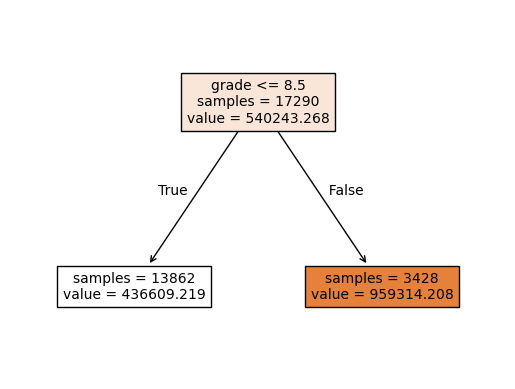

In [26]:
# Visualize your decision stump
from sklearn.tree import plot_tree 
plot_tree(dt, feature_names = X.columns.tolist(), impurity=False, filled=True, fontsize=10);

In [27]:
dt.score(X_train, y_train) # Score on the train set

0.3291495974528278

In [29]:
dt.score(X_test, y_test) # Score on the test set

0.28817946607230793

- How do these scores compare to the previous scores? 

Let's try depth 10. 

In [ ]:
dt = DecisionTreeRegressor(max_depth=40, random_state=123) # max_depth= 40, 
dt.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,40
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,123
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [34]:
dt.score(X_train, y_train) # Score on the train set

0.9992939418916892

In [35]:
dt.score(X_test, y_test) # Score on the test set

0.5549047773135557

Any improvements? Which depth should we pick? 

<br><br>

## Single validation set

We are using the test data again and again. How about creating a validation set to pick the right depth and assessing the final model on the test set?   

In [36]:
# Create a validation set 
X_tr, X_valid, y_tr, y_valid = train_test_split(X_train, y_train, test_size=0.2, random_state=123)

In [41]:
tr_scores = []
valid_scores = []
depths = np.arange(1, 35, 2)

for depth in depths:  
    # Create and fit a decision tree model for the given depth  
    dt = DecisionTreeRegressor(max_depth=depth, random_state=123)
    dt.fit(X_tr, y_tr)
    
    # Calculate and append r2 scores on the training and validation sets
    tr_scores.append(dt.score(X_train, y_train))
    valid_scores.append(dt.score(X_valid, y_valid))
    
results_single_valid_df = pd.DataFrame({"train_score": tr_scores, 
                           "valid_score": valid_scores},index = depths)
results_single_valid_df

,train_score,valid_score
1,0.329141,0.354447
3,0.560295,0.530357
5,0.677051,0.624073
7,0.744915,0.642049
9,0.789740,0.610820
11,0.825687,0.592371
13,0.853029,0.575496
15,0.872208,0.550568
17,0.887827,0.543777
19,0.891996,0.516286


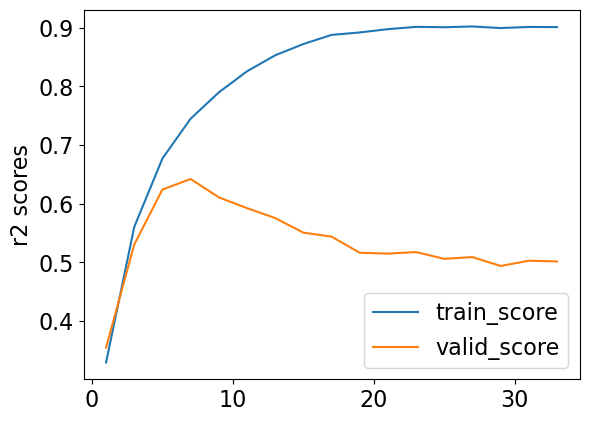

In [42]:
results_single_valid_df[['train_score', 'valid_score']].plot(ylabel='r2 scores');

What depth gives the "best" validation score? 

In [43]:
# What depth gives the "best" validation score?
best_depth = results_single_valid_df['valid_score'].idxmax() 
best_depth

7

## Cross-validation

In [46]:
from sklearn.model_selection import cross_validate

depths = np.arange(1, 35, 2)

cv_train_scores = []
cv_valid_scores = []
for depth in depths: 
    # Create and fit a decision tree model for the given depth   
    dt = DecisionTreeRegressor(max_depth = depth, random_state=123)

    # Carry out cross-validation
    scores = cross_validate(dt, X_train, y_train, cv=5, return_train_score=True)
    cv_train_scores.append(scores['train_score'].mean())
    cv_valid_scores.append(scores['test_score'].mean())


In [47]:
results_df = pd.DataFrame({"train_score": cv_train_scores, 
                           "valid_score": cv_valid_scores
                           },
                           index=depths
                            )
results_df

,train_score,valid_score
1,0.329258,0.330124
3,0.557519,0.533913
5,0.683848,0.621457
7,0.764105,0.639497
9,0.828366,0.600525
11,0.881977,0.558064
13,0.923014,0.536469
15,0.951583,0.526115
17,0.971126,0.490707
19,0.984035,0.476988


In [ ]:
results_df[['train_score', 'valid_score']].plot(ylabel='r2 score', title='Housing price prediction depth vs. r2 score');

What's the "best" depth with cross-validation? 

In [ ]:
best_depth = results_df['valid_score'].idxmax()
best_depth

### Discuss the following questions in your group

1.	At which depth(s) are we underfitting? At which depth(s) are we overfitting?
2.	Above, we chose the depth that gives us the best cross-validation score. Is it always a good idea to select this depth? What if a simpler model with a smaller max_depth gives nearly the same cross-validation score?
3.	If our main concern is test scores, why don't we use the test set during training?
4.	Do you trust our hyperparameter optimization process? In other words, do you believe we've found the best possible depth?

<br><br>

## Assessing on the test set

In [ ]:
# Train a model with the best depth of the full training data
dt_final = DecisionTreeRegressor(max_depth=best_depth, random_state=123)
dt_final.fit(X_train, y_train)
dt_final.score(X_train, y_train)

In [ ]:
dt_final.score(X_test, y_test)

How do these scores compare to the scores when we used a single validation set? 

### Learned model 

In [ ]:
#What's the depth of the model? 
dt_final.get_depth()

In [ ]:
# plot_tree(dt_final, feature_names = X_train.columns.tolist(), impurity=False, filled=True);

In [ ]:
# Which features are the most important ones?
dt_final.feature_importances_

Let's examine feature importances. 

In [ ]:
df = pd.DataFrame( 
    data = {
        "features": dt_final.feature_names_in_,
        "feature_importances": dt_final.feature_importances_
    }
)
df.sort_values("feature_importances", ascending=False)

<br><br>

## Concepts we revised in this demo

- Exploratory data analysis
- Baselines
- Data splitting: train, test, validation sets
- Cross validation
- Underfitting, overfitting, the fundamental tradeoff
- The golden rule of supervised ML

## Typical steps to build a supervised machine learning model

- Ensure the data is appropriate for your task (e.g., labeled data, suitable features).
- Split the data into training and testing sets.
- Perform exploratory data analysis (EDA) on the training data to understand distributions, identify patterns, and detect potential issues.
- Preprocess and encode features (e.g., handle missing values, scale features, encode categorical variables).
    - coming up 
- Build a baseline model to establish a performance benchmark.
- Train multiple candidate models on the training data.
    - coming up  
- Select promising models and perform hyperparameter tuning using cross-validation.
    - coming up 
- Evaluate the generalization performance of the best model on the test set.


<br><br>